In [ ]:
!pip install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.5 MB/s eta 0:00:00


In [ ]:
!pip install medmnist pytorch-fid

In [ ]:
import os
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
from torchvision.utils import save_image, make_grid

from torch.utils.data import DataLoader, TensorDataset

from medmnist import BloodMNIST

from pytorch_fid import fid_score

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


# Part 1

In [ ]:
def sample_sine(n=512):
    x = np.random.uniform(-3, 3, n)
    y = np.sin(x)
    return np.stack([x, y], axis=1)

def sample_spiral(n=512):
    theta = np.sqrt(np.random.rand(n)) * 4 * np.pi
    r = theta
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return np.stack([x, y], axis=1)

def sample_gaussians(n=512):
    centers = [(2,2), (-2,-2), (2,-2), (-2,2)]
    data = []
    for _ in range(n):
        cx, cy = centers[np.random.randint(0,4)]
        point = np.random.randn(2)*0.3 + np.array([cx, cy])
        data.append(point)
    return np.array(data)

def sample_noisy_curve(n=512):
    x = np.random.uniform(-3, 3, n)
    eps = np.random.normal(0, 0.2, n)
    y = np.sin(2*x) + 0.3*np.cos(5*x) + eps
    return np.stack([x, y], axis=1)

In [ ]:
DATASET = "sine"

def get_data(n=512):
    if DATASET == "sine":
        return sample_sine(n)
    elif DATASET == "spiral":
        return sample_spiral(n)
    elif DATASET == "gaussian":
        return sample_gaussians(n)
    elif DATASET == "noisy":
        return sample_noisy_curve(n)

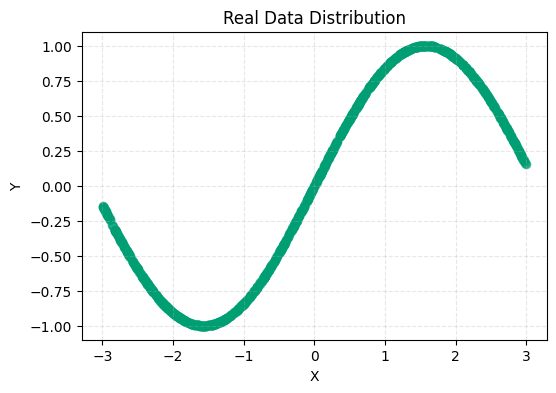

In [ ]:
data = get_data(1000)

plt.figure(figsize=(6,4))

plt.scatter(
    data[:,0],
    data[:,1],
    color="#009E73",
    alpha=0.6
)

plt.title("Real Data Distribution")
plt.xlabel("X")
plt.ylabel("Y")

plt.grid(True, linestyle="--", alpha=0.3)

plt.show()

In [ ]:
latent_dim = 2

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 2)
        )

    def forward(self, z):
        return self.model(z)

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()

g_optimizer = optim.Adam(G.parameters(), lr=0.001)
d_optimizer = optim.Adam(D.parameters(), lr=0.001)

In [ ]:
epochs = 10000 # Firstly ran at 5000 but curve was not that better than tried 10000
batch_size = 256
lr = 0.0003

for epoch in range(epochs):

    real_data = get_data(batch_size)
    real_data = torch.tensor(real_data, dtype=torch.float32).to(device)

    real_labels = torch.ones(batch_size, 1).to(device)
    fake_labels = torch.zeros(batch_size, 1).to(device)

    # Training of Discriminator
    z = torch.randn(batch_size, latent_dim).to(device)
    fake_data = G(z)

    real_loss = criterion(D(real_data), real_labels)
    fake_loss = criterion(D(fake_data.detach()), fake_labels)

    d_loss = real_loss + fake_loss

    d_optimizer.zero_grad()
    d_loss.backward()
    d_optimizer.step()

    # Training of Generator
    z = torch.randn(batch_size, latent_dim).to(device)
    fake_data = G(z)

    g_loss = criterion(D(fake_data), real_labels)

    g_optimizer.zero_grad()
    g_loss.backward()
    g_optimizer.step()

    if epoch % 200 == 0:
        print(f"Epoch {epoch} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

Epoch 0 | D Loss: 1.4080 | G Loss: 0.7103
Epoch 200 | D Loss: 1.5899 | G Loss: 1.4366
Epoch 400 | D Loss: 1.5090 | G Loss: 0.7718
Epoch 600 | D Loss: 1.1591 | G Loss: 0.9002
Epoch 800 | D Loss: 1.3336 | G Loss: 0.7238
Epoch 1000 | D Loss: 1.3592 | G Loss: 0.6988
Epoch 1200 | D Loss: 1.3794 | G Loss: 0.7040
Epoch 1400 | D Loss: 1.3714 | G Loss: 0.7046
Epoch 1600 | D Loss: 1.3904 | G Loss: 0.7048
Epoch 1800 | D Loss: 1.3862 | G Loss: 0.6929
Epoch 2000 | D Loss: 1.3793 | G Loss: 0.6823
Epoch 2200 | D Loss: 1.3803 | G Loss: 0.7060
Epoch 2400 | D Loss: 1.3712 | G Loss: 0.6745
Epoch 2600 | D Loss: 1.4344 | G Loss: 0.8160
Epoch 2800 | D Loss: 1.2588 | G Loss: 0.7600
Epoch 3000 | D Loss: 1.3738 | G Loss: 0.7027
Epoch 3200 | D Loss: 1.3768 | G Loss: 0.6963
Epoch 3400 | D Loss: 1.2627 | G Loss: 0.7524
Epoch 3600 | D Loss: 1.3673 | G Loss: 0.7206
Epoch 3800 | D Loss: 1.4291 | G Loss: 0.6464
Epoch 4000 | D Loss: 1.3895 | G Loss: 0.6855
Epoch 4200 | D Loss: 1.2913 | G Loss: 0.7218
Epoch 4400 | D Lo

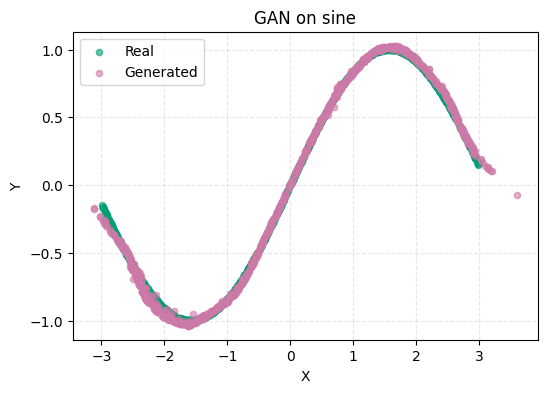

In [ ]:
real = get_data(1000)

z = torch.randn(1000, latent_dim).to(device)
generated = G(z).detach().cpu().numpy()

plt.figure(figsize=(6,4))

real_color = "#009E73"
gen_color = "#CC79A7"

plt.scatter(real[:,0], real[:,1],
            alpha=0.6, label="Real",
            color=real_color, s=20)

plt.scatter(generated[:,0], generated[:,1],
            alpha=0.6, label="Generated",
            color=gen_color, s=20)

plt.legend()
plt.title(f"GAN on {DATASET}")
plt.xlabel("X")
plt.ylabel("Y")

plt.grid(True, linestyle="--", alpha=0.3)

plt.show()

In [ ]:
def sample_gaussians(n=512):
    centers = [(2,2), (-2,-2), (2,-2), (-2,2)]
    data = []

    for _ in range(n):
        cx, cy = centers[np.random.randint(0,4)]
        point = np.random.randn(2)*0.3 + np.array([cx, cy])
        data.append(point)

    return np.array(data)

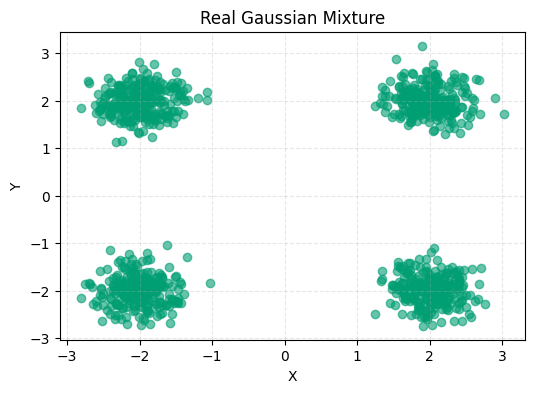

In [ ]:
data = sample_gaussians(1000)

plt.figure(figsize=(6,4))

plt.scatter(
    data[:,0],
    data[:,1],
    color="#009E73",
    alpha=0.6
)

plt.title("Real Gaussian Mixture")
plt.xlabel("X")
plt.ylabel("Y")

plt.grid(True, linestyle="--", alpha=0.3)

plt.show()

In [ ]:
epochs = 5000
batch_size = 256

for epoch in range(epochs):

    real_data = sample_gaussians(batch_size)
    real_data = torch.tensor(real_data, dtype=torch.float32).to(device)

    real_labels = torch.ones(batch_size, 1).to(device)
    fake_labels = torch.zeros(batch_size, 1).to(device)

    # Training of Discriminator
    z = torch.randn(batch_size, latent_dim).to(device)
    fake_data = G(z)

    real_loss = criterion(D(real_data), real_labels)
    fake_loss = criterion(D(fake_data.detach()), fake_labels)

    d_loss = real_loss + fake_loss

    d_optimizer.zero_grad()
    d_loss.backward()
    d_optimizer.step()

    # Training of Generator
    z = torch.randn(batch_size, latent_dim).to(device)
    fake_data = G(z)

    g_loss = criterion(D(fake_data), real_labels)

    g_optimizer.zero_grad()
    g_loss.backward()
    g_optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

Epoch 0 | D Loss: 5.3943 | G Loss: 0.6728
Epoch 500 | D Loss: 1.0425 | G Loss: 1.1743
Epoch 1000 | D Loss: 1.2654 | G Loss: 0.9245
Epoch 1500 | D Loss: 1.3291 | G Loss: 0.7999
Epoch 2000 | D Loss: 1.3074 | G Loss: 0.8338
Epoch 2500 | D Loss: 1.3692 | G Loss: 0.8408
Epoch 3000 | D Loss: 1.3634 | G Loss: 0.7279
Epoch 3500 | D Loss: 1.3606 | G Loss: 0.7539
Epoch 4000 | D Loss: 1.3894 | G Loss: 0.7964
Epoch 4500 | D Loss: 1.3682 | G Loss: 0.7480


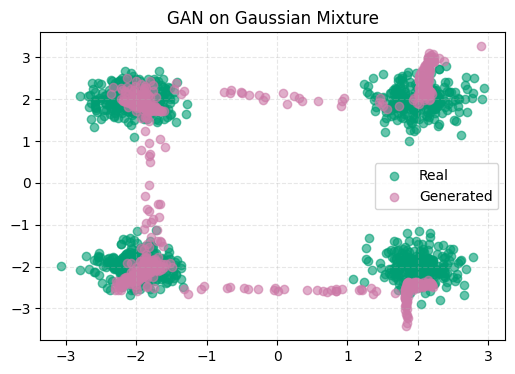

In [ ]:
real = sample_gaussians(1000)

z = torch.randn(1000, latent_dim).to(device)
generated = G(z).detach().cpu().numpy()

plt.figure(figsize=(6,4))

plt.scatter(real[:,0], real[:,1],
            alpha=0.6, label="Real",
            color="#009E73")

plt.scatter(generated[:,0], generated[:,1],
            alpha=0.6, label="Generated",
            color="#CC79A7")

plt.legend()
plt.title("GAN on Gaussian Mixture")
plt.grid(True, linestyle="--", alpha=0.3)

plt.show()

In [ ]:
class Generator_Mod(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 2)
        )

    def forward(self, z):
        return self.model(z)

In [ ]:
G_mod = Generator_Mod().to(device)

g_optimizer_mod = optim.Adam(G_mod.parameters(), lr=0.0005)

In [ ]:
epochs = 10000

for epoch in range(epochs):

    real_data = sample_gaussians(batch_size)
    real_data = torch.tensor(real_data, dtype=torch.float32).to(device)

    real_labels = torch.ones(batch_size, 1).to(device)
    fake_labels = torch.zeros(batch_size, 1).to(device)

    # Training Discriminator
    z = torch.randn(batch_size, latent_dim).to(device)
    fake_data = G_mod(z)

    real_loss = criterion(D(real_data), real_labels)
    fake_loss = criterion(D(fake_data.detach()), fake_labels)

    d_loss = real_loss + fake_loss

    d_optimizer.zero_grad()
    d_loss.backward()
    d_optimizer.step()

    # Training Generator
    z = torch.randn(batch_size, latent_dim).to(device)
    fake_data = G_mod(z)

    g_loss = criterion(D(fake_data), real_labels)

    g_optimizer_mod.zero_grad()
    g_loss.backward()
    g_optimizer_mod.step()

    if epoch % 500 == 0:
        print(f"[MOD] Epoch {epoch} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

[MOD] Epoch 0 | D Loss: 0.8192 | G Loss: 2.2548
[MOD] Epoch 500 | D Loss: 0.6016 | G Loss: 1.5685
[MOD] Epoch 1000 | D Loss: 0.6608 | G Loss: 1.6045
[MOD] Epoch 1500 | D Loss: 0.6381 | G Loss: 1.4723
[MOD] Epoch 2000 | D Loss: 0.9697 | G Loss: 1.1563
[MOD] Epoch 2500 | D Loss: 1.1834 | G Loss: 0.9568
[MOD] Epoch 3000 | D Loss: 1.2925 | G Loss: 0.8611
[MOD] Epoch 3500 | D Loss: 1.2771 | G Loss: 0.8368
[MOD] Epoch 4000 | D Loss: 1.3501 | G Loss: 0.7538
[MOD] Epoch 4500 | D Loss: 1.3814 | G Loss: 0.7211
[MOD] Epoch 5000 | D Loss: 1.3627 | G Loss: 0.7655
[MOD] Epoch 5500 | D Loss: 1.3755 | G Loss: 0.7089
[MOD] Epoch 6000 | D Loss: 1.3697 | G Loss: 0.7339
[MOD] Epoch 6500 | D Loss: 1.3623 | G Loss: 0.7227
[MOD] Epoch 7000 | D Loss: 1.3834 | G Loss: 0.7054
[MOD] Epoch 7500 | D Loss: 1.3663 | G Loss: 0.7374
[MOD] Epoch 8000 | D Loss: 1.3882 | G Loss: 0.7049
[MOD] Epoch 8500 | D Loss: 1.3552 | G Loss: 0.7571
[MOD] Epoch 9000 | D Loss: 1.3870 | G Loss: 0.7426
[MOD] Epoch 9500 | D Loss: 1.3207 |

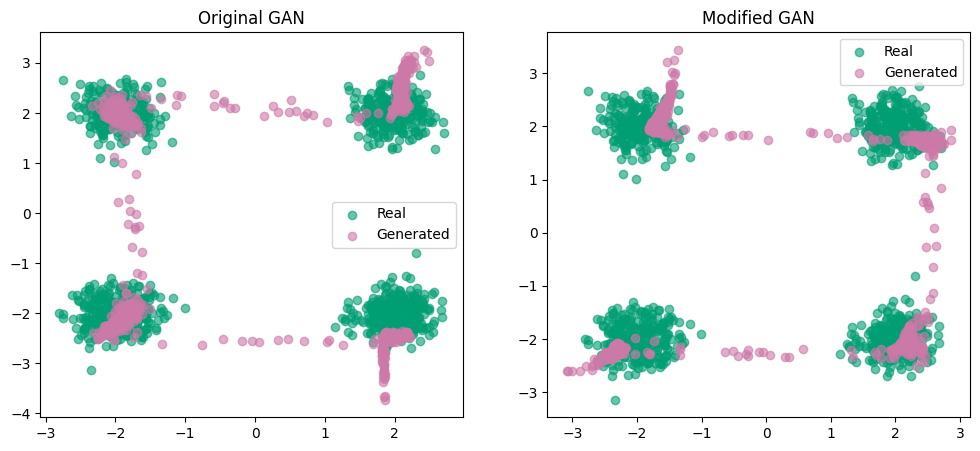

In [ ]:
real = sample_gaussians(1000)

z = torch.randn(1000, latent_dim).to(device)

generated_original = G(z).detach().cpu().numpy()
generated_modified = G_mod(z).detach().cpu().numpy()

plt.figure(figsize=(12,5))

real_color = "#009E73"
gen_color = "#CC79A7"

# This is the Original GAN code
plt.subplot(1,2,1)
plt.scatter(real[:,0], real[:,1], alpha=0.6, label="Real", color=real_color)
plt.scatter(generated_original[:,0], generated_original[:,1], alpha=0.6, label="Generated", color=gen_color)
plt.title("Original GAN")
plt.legend()

# This is the Modified GAN code
plt.subplot(1,2,2)
plt.scatter(real[:,0], real[:,1], alpha=0.6, label="Real", color=real_color)
plt.scatter(generated_modified[:,0], generated_modified[:,1], alpha=0.6, label="Generated", color=gen_color)
plt.title("Modified GAN")
plt.legend()

plt.show()

In [ ]:
if os.path.exists("real"):
    shutil.rmtree("real")
if os.path.exists("original"):
    shutil.rmtree("original")
if os.path.exists("modified"):
    shutil.rmtree("modified")

os.makedirs("real", exist_ok=True)
os.makedirs("original", exist_ok=True)
os.makedirs("modified", exist_ok=True)

real = sample_gaussians(1000)

z = torch.randn(1000, latent_dim).to(device)

generated_original = G(z).detach().cpu().numpy()
generated_modified = G_mod(z).detach().cpu().numpy()

num_samples = 100

for i in range(num_samples):
    img = real[i].reshape(1, 1, 2)
    save_image(torch.tensor(img, dtype=torch.float32), f"real/{i}.png", normalize=True)

for i in range(num_samples):
    img = generated_original[i].reshape(1, 1, 2)
    save_image(torch.tensor(img, dtype=torch.float32), f"original/{i}.png", normalize=True)

for i in range(num_samples):
    img = generated_modified[i].reshape(1, 1, 2)
    save_image(torch.tensor(img, dtype=torch.float32), f"modified/{i}.png", normalize=True)

fid_original = fid_score.calculate_fid_given_paths(
    ["real", "original"],
    batch_size=32,
    device=device,
    dims=2048
)

fid_modified = fid_score.calculate_fid_given_paths(
    ["real", "modified"],
    batch_size=32,
    device=device,
    dims=2048
)

print("Original GAN FID Score:", fid_original)
print("Modified GAN FID Score:", fid_modified)

100%|██████████| 4/4 [00:00<00:00,  8.59it/s]


Original GAN FID Score: 0.09268203576183964
Modified GAN FID Score: 0.03318666654464053


# Part 2.1

Dataset & Class Distribution

100%|██████████| 35.5M/35.5M [00:02<00:00, 12.0MB/s]


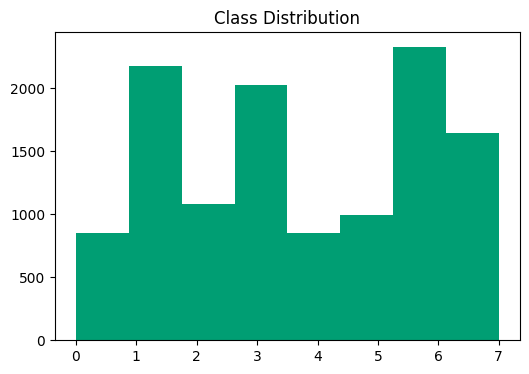

Dataset size: 11959


In [ ]:
transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize(16),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = BloodMNIST(split='train', transform=transform, download=True)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

# Class distribution
labels = [label.item() for _, label in dataset]

plt.figure(figsize=(6,4))
plt.hist(labels, bins=8, color="#009E73")
plt.title("Class Distribution")
plt.show()

print("Dataset size:", len(dataset))

Visualising Real Images

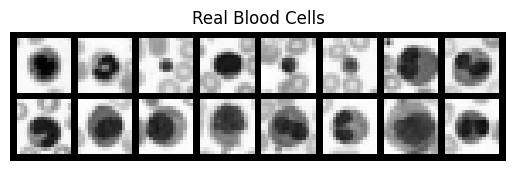

In [ ]:
real_batch,_ = next(iter(loader))

plt.imshow(torchvision.utils.make_grid(real_batch[:16], normalize=True).permute(1,2,0))
plt.title("Real Blood Cells")
plt.axis('off')
plt.show()

Code for Generator

In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(100,128,4,1,0),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128,64,4,2,1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64,1,4,2,1),
            nn.Tanh()
        )

    def forward(self,z):
        return self.net(z)

Code for Discriminator

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1,64,4,2,1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64,128,4,2,1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            nn.Linear(128,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.net(x)

Initialising

In [ ]:
G = Generator().to(device)
D = Discriminator().to(device)

optG = torch.optim.Adam(G.parameters(), 0.0003, betas=(0.5,0.999))
optD = torch.optim.Adam(D.parameters(), 0.0001, betas=(0.5,0.999))

loss = nn.BCELoss()

Training & Loss Tracking

In [ ]:
g_losses = []
d_losses = []

epochs = 110

for epoch in range(epochs):
    for real,_ in loader:

        real = real.to(device)
        b = real.size(0)

        z = torch.randn(b,100,1,1).to(device)
        fake = G(z)

        # Discriminator
        lD = loss(D(real), torch.ones(b,1).to(device)) + \
             loss(D(fake.detach()), torch.zeros(b,1).to(device))

        optD.zero_grad()
        lD.backward()
        optD.step()

        # Generator
        lG = loss(D(fake), torch.ones(b,1).to(device))

        optG.zero_grad()
        lG.backward()
        optG.step()

    g_losses.append(lG.item())
    d_losses.append(lD.item())

    print(f"Epoch {epoch+1} | D: {lD:.3f} | G: {lG:.3f}")

Epoch 1 | D: 0.834 | G: 1.290
Epoch 2 | D: 1.428 | G: 1.100
Epoch 3 | D: 0.829 | G: 1.342
Epoch 4 | D: 1.173 | G: 1.061
Epoch 5 | D: 0.701 | G: 1.706
Epoch 6 | D: 1.019 | G: 1.015
Epoch 7 | D: 1.002 | G: 1.066
Epoch 8 | D: 0.994 | G: 1.027
Epoch 9 | D: 0.862 | G: 1.447
Epoch 10 | D: 0.794 | G: 1.362
Epoch 11 | D: 0.969 | G: 0.948
Epoch 12 | D: 1.018 | G: 1.040
Epoch 13 | D: 0.988 | G: 1.198
Epoch 14 | D: 0.884 | G: 1.485
Epoch 15 | D: 0.880 | G: 1.315
Epoch 16 | D: 0.614 | G: 1.877
Epoch 17 | D: 0.867 | G: 1.549
Epoch 18 | D: 0.827 | G: 1.295
Epoch 19 | D: 0.928 | G: 1.444
Epoch 20 | D: 0.995 | G: 1.064
Epoch 21 | D: 0.731 | G: 1.623
Epoch 22 | D: 0.761 | G: 1.540
Epoch 23 | D: 0.935 | G: 1.016
Epoch 24 | D: 0.858 | G: 1.362
Epoch 25 | D: 0.879 | G: 1.170
Epoch 26 | D: 0.804 | G: 1.142
Epoch 27 | D: 0.922 | G: 1.090
Epoch 28 | D: 0.889 | G: 1.236
Epoch 29 | D: 0.872 | G: 1.167
Epoch 30 | D: 0.907 | G: 1.160
Epoch 31 | D: 0.862 | G: 1.199
Epoch 32 | D: 0.819 | G: 1.348
Epoch 33 | D: 0.8

Below is the code for Loss Plot

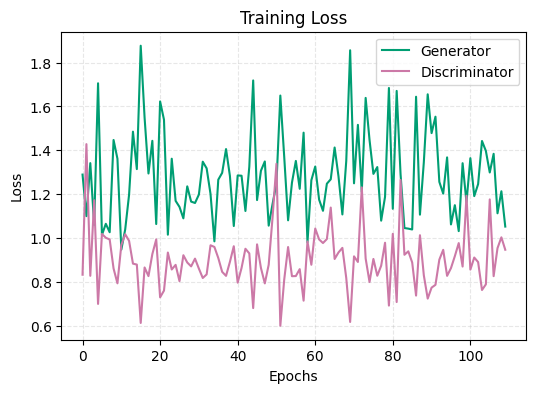

In [ ]:
plt.figure(figsize=(6,4))

plt.plot(g_losses, label="Generator", color="#009E73")   # green
plt.plot(d_losses, label="Discriminator", color="#CC79A7")  # purple

plt.legend()
plt.title("Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.grid(True, linestyle="--", alpha=0.3)

plt.show()

Generating and Comparing Fake Images

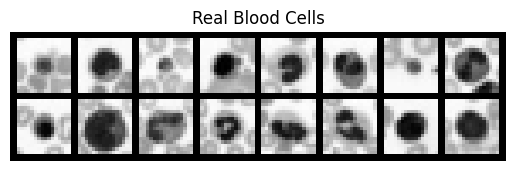

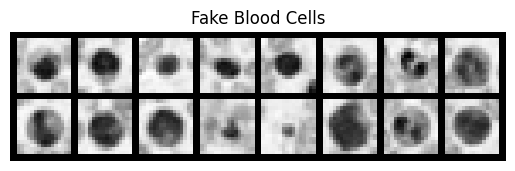

In [ ]:
real_batch,_ = next(iter(loader))
plt.imshow(torchvision.utils.make_grid(real_batch[:16], normalize=True).permute(1,2,0))
plt.title("Real Blood Cells")
plt.axis('off')
plt.show()

z = torch.randn(16,100,1,1).to(device)
fake = G(z).detach().cpu()
plt.imshow(torchvision.utils.make_grid(fake, normalize=True).permute(1,2,0))
plt.title("Fake Blood Cells")
plt.axis('off')
plt.show()

FID (Quantitative Evaluation)

In [ ]:
os.makedirs("real", exist_ok=True)
os.makedirs("fake", exist_ok=True)


for i,(img,_) in enumerate(loader):
    if i > 5: break
    for j in range(img.size(0)):
        save_image(img[j], f"real/{i}_{j}.png", normalize=True)


for i in range(6):
    z = torch.randn(64,100,1,1).to(device)
    fake = G(z).detach().cpu()
    for j in range(fake.size(0)):
        save_image(fake[j], f"fake/{i}_{j}.png", normalize=True)


fid = fid_score.calculate_fid_given_paths(
    ["real", "fake"],
    batch_size=32,
    device=device,
    dims=2048
)

print("FID Score:", fid)

100%|██████████| 12/12 [00:01<00:00,  7.22it/s]


FID Score: 112.71282573588559


# Part 2.2

Uploading the Dataset File

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Wednesday-workingHours.pcap_ISCX.csv to Wednesday-workingHours.pcap_ISCX (2).csv


Exploring the Dataset

In [ ]:
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name, encoding='latin1')
df.columns = df.columns.str.strip()
df = df[df['Label'].isin([
    'BENIGN',
    'DoS Hulk',
    'DoS GoldenEye',
    'DoS slowloris',
    'DoS Slowhttptest'
])]
print("Shape:", df.shape)
print(df['Label'].value_counts())

Shape: (692692, 79)
Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Name: count, dtype: int64


In [ ]:
df = df.select_dtypes(include=[np.number])

df = df.replace([np.inf, -np.inf], np.nan).dropna()

print("Cleaned shape:", df.shape)

Cleaned shape: (691395, 78)


In [ ]:
df = pd.read_csv(file_name, encoding='latin1')
df.columns = df.columns.str.strip()

In [ ]:
labels = df['Label'].copy()

Shape: (692703, 79)

Class counts:
Label
BENIGN              440031
DoS Hulk            231073
DoS GoldenEye        10293
DoS slowloris         5796
DoS Slowhttptest      5499
Heartbleed              11
Name: count, dtype: int64


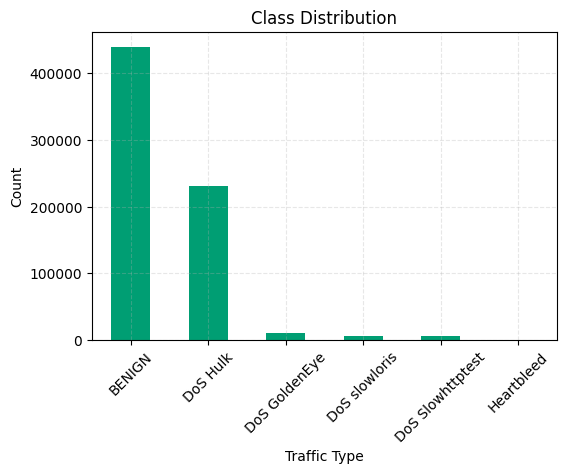

In [ ]:
# Checking the  dataset shape
print("Shape:", df.shape)

# Checking class distribution
print("\nClass counts:")
print(df['Label'].value_counts())

# Plotting class distribution
plt.figure(figsize=(6,4))

df['Label'].value_counts().plot(
    kind='bar',
    color="#009E73"
)

plt.title("Class Distribution")
plt.xlabel("Traffic Type")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.3)

plt.show()

This is the code for Generator

In [ ]:
class Generator(nn.Module):
    def __init__(self, z_dim, output_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(z_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Linear(512, output_dim),
            nn.Sigmoid()     # if MinMax scaled data
        )

    def forward(self, x):
        return self.net(x)

This is code for Discriminator

In [ ]:
class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),

            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

Initialising

In [ ]:
latent_dim = 32
input_dim = data.shape[1]

G = Generator(latent_dim, input_dim)
D = Discriminator(input_dim)

criterion = nn.BCELoss()

g_opt = optim.Adam(G.parameters(), lr=0.0002)
d_opt = optim.Adam(D.parameters(), lr=0.0002)

This is the code for Training Loop

In [ ]:
latent_dim = 64
input_dim = data.shape[1]

G = Generator(latent_dim, input_dim)
D = Discriminator(input_dim)

criterion = nn.BCELoss()

g_opt = optim.Adam(G.parameters(), lr=0.0001)
d_opt = optim.Adam(D.parameters(), lr=0.0001)

epochs = 500
batch_size = 128

g_losses = []
d_losses = []


data_tensor = torch.tensor(data, dtype=torch.float32)

for epoch in range(epochs):

    idx = torch.randint(0, data_tensor.shape[0], (batch_size,))
    real = data_tensor[idx]


    real_labels = torch.ones(batch_size,1) * 0.9
    fake_labels = torch.zeros(batch_size,1)


    z = torch.randn(batch_size, latent_dim)
    fake = G(z)

    d_loss = criterion(D(real), real_labels) + \
             criterion(D(fake.detach()), fake_labels)

    d_opt.zero_grad()
    d_loss.backward()
    d_opt.step()


    z = torch.randn(batch_size, latent_dim)
    fake = G(z)

    g_loss = criterion(D(fake), real_labels)

    g_opt.zero_grad()
    g_loss.backward()
    g_opt.step()

    g_losses.append(g_loss.item())
    d_losses.append(d_loss.item())

    if epoch % 50 == 0:
        print(f"Epoch {epoch} | D={d_loss:.3f} | G={g_loss:.3f}")

Epoch 0 | D=1.388 | G=0.731
Epoch 50 | D=0.788 | G=1.039
Epoch 100 | D=0.404 | G=2.631
Epoch 150 | D=0.370 | G=3.649
Epoch 200 | D=0.353 | G=4.031
Epoch 250 | D=0.352 | G=4.307
Epoch 300 | D=0.349 | G=4.498
Epoch 350 | D=0.351 | G=4.788
Epoch 400 | D=0.346 | G=4.888
Epoch 450 | D=0.344 | G=4.679


Code for Loss Plot

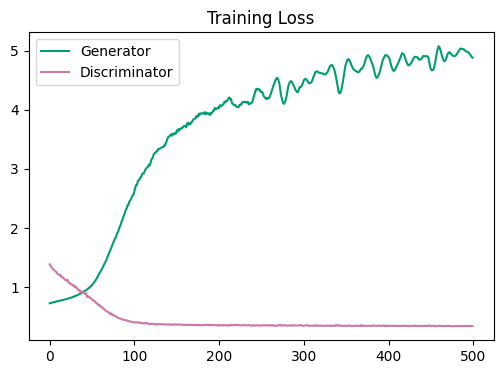

In [ ]:

plt.figure(figsize=(6,4))

plt.plot(g_losses, label="Generator", color="#009E73")
plt.plot(d_losses, label="Discriminator", color="#CC79A7")

plt.legend()
plt.title("Training Loss")
plt.show()

T-SNE

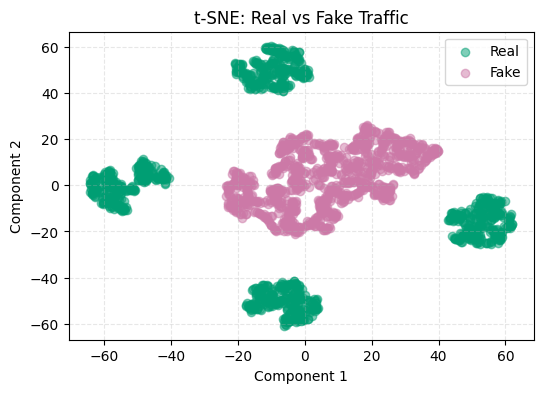

In [ ]:
z = torch.randn(1000, latent_dim)
fake_data = G(z).detach().numpy()

real_data = data[:1000]

combined = np.vstack([real_data, fake_data])

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_result = tsne.fit_transform(combined)

real_tsne = tsne_result[:1000]
fake_tsne = tsne_result[1000:]

plt.figure(figsize=(6,4))

plt.scatter(real_tsne[:,0], real_tsne[:,1],
            alpha=0.5, label="Real", color="#009E73")

plt.scatter(fake_tsne[:,0], fake_tsne[:,1],
            alpha=0.5, label="Fake", color="#CC79A7")

plt.legend()
plt.title("t-SNE: Real vs Fake Traffic")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True, linestyle="--", alpha=0.3)

plt.show()

In [ ]:
if os.path.exists("real"):
    shutil.rmtree("real")

if os.path.exists("fake"):
    shutil.rmtree("fake")

os.makedirs("real", exist_ok=True)
os.makedirs("fake", exist_ok=True)


num_samples = 100

real_batch = data[:num_samples]   # numpy array

for i in range(num_samples):

    sample = real_batch[i]


    side = int(np.ceil(np.sqrt(len(sample))))
    padded = np.pad(sample, (0, side*side-len(sample)))
    img = padded.reshape(side, side)

    plt.imsave(f"real/{i}.png", img, cmap="gray")

z = torch.randn(num_samples, latent_dim)
fake = G(z).detach().numpy()

for i in range(num_samples):

    sample = fake[i]

    side = int(np.ceil(np.sqrt(len(sample))))
    padded = np.pad(sample, (0, side*side-len(sample)))
    img = padded.reshape(side, side)

    plt.imsave(f"fake/{i}.png", img, cmap="gray")

fid = fid_score.calculate_fid_given_paths(
    ["real", "fake"],
    batch_size=32,
    device="cpu",
    dims=2048
)

print(" FID Score:", fid)

100%|██████████| 4/4 [00:24<00:00,  6.01s/it]
/usr/local/lib/python3.12/dist-packages/pytorch_fid/fid_score.py:188: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)


 FID Score: 96.56170453882328


# Part 2.3

Uploading the File of the Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving full_numpy_bitmap_pizza.npy to full_numpy_bitmap_pizza (1).npy


In [ ]:
file_name = list(uploaded.keys())[0]
print("Uploaded:", file_name)

Uploaded: full_numpy_bitmap_pizza (1).npy


Exploring the Dataset

Dataset shape: (130371, 784)


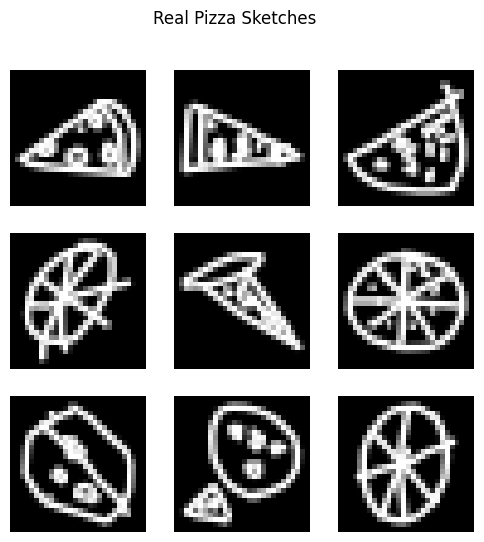

In [ ]:
data = np.load(file_name)

print("Dataset shape:", data.shape)  # (N, 784)

# Normalizinng & reshaping
data = data / 255.0
data = data.reshape(-1, 1, 28, 28)

# Showing the samples
plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(data[i][0], cmap="gray")
    plt.axis("off")

plt.suptitle("Real Pizza Sketches")
plt.show()

Converting to Tensor &  DataLoader

In [ ]:

data_tensor = torch.tensor(data, dtype=torch.float32)

dataset = TensorDataset(data_tensor)
loader = DataLoader(dataset, batch_size=128, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


Code of the Generator (DCGAN)

In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(100, 256, 7, 1, 0),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 1, 3, 1, 1),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)

Code for the Discriminator

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1),   # 28→14
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1), # 14→7
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Flatten(),
            nn.Linear(128*7*7, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
G = Generator().to(device)
D = Discriminator().to(device)

import torch.optim as optim

g_opt = optim.Adam(G.parameters(), 0.0002)
d_opt = optim.Adam(D.parameters(), 0.0002)

criterion = nn.BCELoss()

Code for the Training loop

In [ ]:
epochs = 30

g_losses = []
d_losses = []

max_batches = 200

for epoch in range(epochs):
    print(f"\n Epoch {epoch+1}/{epochs}")

    for batch_idx, (real,) in enumerate(loader):

        if batch_idx > max_batches:
            break

        real = real.to(device)
        b = real.size(0)

        real_labels = torch.ones(b,1).to(device)
        fake_labels = torch.zeros(b,1).to(device)

        z = torch.randn(b, 100, 1, 1).to(device)
        fake = G(z)

        d_real = D(real)
        d_fake = D(fake.detach())

        d_loss = criterion(d_real, real_labels) + \
                 criterion(d_fake, fake_labels)

        d_opt.zero_grad()
        d_loss.backward()
        d_opt.step()


        z = torch.randn(b, 100, 1, 1).to(device)
        fake = G(z)

        g_loss = criterion(D(fake), real_labels)

        g_opt.zero_grad()
        g_loss.backward()
        g_opt.step()


        if batch_idx % 20 == 0:
            print(f"Batch {batch_idx}/{max_batches} | D: {d_loss:.3f} | G: {g_loss:.3f}")

    g_losses.append(g_loss.item())
    d_losses.append(d_loss.item())

    print(f" End Epoch {epoch+1} | D: {d_loss:.3f} | G: {g_loss:.3f}")


 Epoch 1/30
Batch 0/200 | D: 1.453 | G: 0.805
Batch 20/200 | D: 0.274 | G: 2.765
Batch 40/200 | D: 0.025 | G: 4.846
Batch 60/200 | D: 0.157 | G: 5.774
Batch 80/200 | D: 0.012 | G: 5.888
Batch 100/200 | D: 0.020 | G: 7.339
Batch 120/200 | D: 0.018 | G: 4.594
Batch 140/200 | D: 0.010 | G: 5.677
Batch 160/200 | D: 0.013 | G: 7.027
Batch 180/200 | D: 0.078 | G: 3.257
Batch 200/200 | D: 0.351 | G: 4.143
 End Epoch 1 | D: 0.351 | G: 4.143

 Epoch 2/30
Batch 0/200 | D: 0.069 | G: 6.717
Batch 20/200 | D: 0.008 | G: 9.437
Batch 40/200 | D: 0.006 | G: 6.178
Batch 60/200 | D: 0.012 | G: 4.995
Batch 80/200 | D: 0.016 | G: 4.591
Batch 100/200 | D: 0.018 | G: 9.450
Batch 120/200 | D: 0.004 | G: 9.333
Batch 140/200 | D: 0.004 | G: 7.382
Batch 160/200 | D: 0.006 | G: 5.988
Batch 180/200 | D: 0.004 | G: 6.507
Batch 200/200 | D: 0.003 | G: 6.970
 End Epoch 2 | D: 0.003 | G: 6.970

 Epoch 3/30
Batch 0/200 | D: 0.004 | G: 6.950
Batch 20/200 | D: 0.002 | G: 7.338
Batch 40/200 | D: 0.002 | G: 7.720
Batch 6

Training Loss Plot

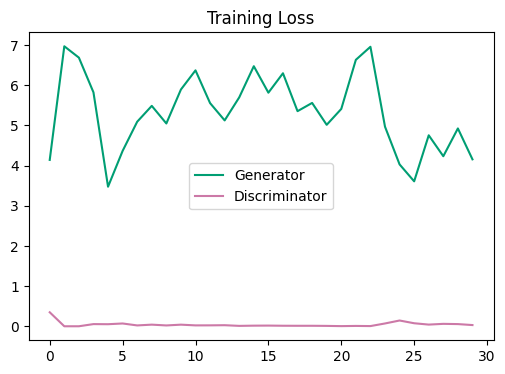

In [ ]:
plt.figure(figsize=(6,4))

plt.plot(g_losses, label="Generator", color="#009E73")
plt.plot(d_losses, label="Discriminator", color="#CC79A7")

plt.legend()
plt.title("Training Loss")
plt.show()

Generating the Fake Imnages

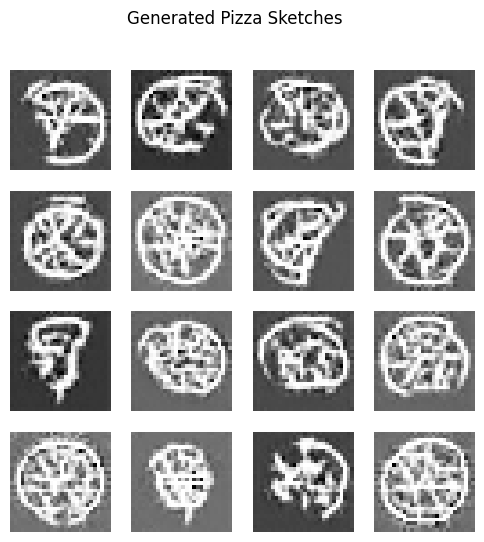

In [ ]:
z = torch.randn(16, 100, 1, 1).to(device)
fake = G(z).detach().cpu()

plt.figure(figsize=(6,6))

for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(fake[i][0], cmap="gray")
    plt.axis("off")

plt.suptitle("Generated Pizza Sketches")
plt.show()

Comparing the Real and Fake Images

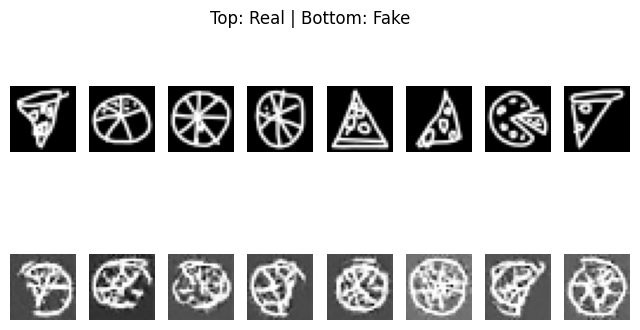

In [ ]:
real_batch, = next(iter(loader))

plt.figure(figsize=(8,4))

for i in range(8):
    plt.subplot(2,8,i+1)
    plt.imshow(real_batch[i][0], cmap="gray")
    plt.axis("off")

for i in range(8):
    plt.subplot(2,8,i+9)
    plt.imshow(fake[i][0], cmap="gray")
    plt.axis("off")

plt.suptitle("Top: Real | Bottom: Fake")
plt.show()

In [ ]:
if os.path.exists("real"):
    shutil.rmtree("real")
if os.path.exists("fake"):
    shutil.rmtree("fake")

os.makedirs("real", exist_ok=True)
os.makedirs("fake", exist_ok=True)

real_batch, = next(iter(loader))

num_real = min(100, real_batch.size(0))  # safe limit

for i in range(num_real):
    save_image(real_batch[i], f"real/{i}.png", normalize=True)

num_fake = num_real

z = torch.randn(num_fake, 100, 1, 1).to(device)
fake = G(z).detach().cpu()

for i in range(fake.size(0)):
    save_image(fake[i], f"fake/{i}.png", normalize=True)

fid = fid_score.calculate_fid_given_paths(
    ["real", "fake"],
    batch_size=32,
    device=device,
    dims=2048
)

print("FID Score:", fid)

100%|██████████| 4/4 [00:00<00:00,  4.83it/s]


FID Score: 115.60460114677714


# Extension 2.3 with cup dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

file_names = list(uploaded.keys())
print("Uploaded files:", file_names)

Saving full_numpy_bitmap_cup.npy to full_numpy_bitmap_cup.npy
Uploaded files: ['full_numpy_bitmap_cup.npy']


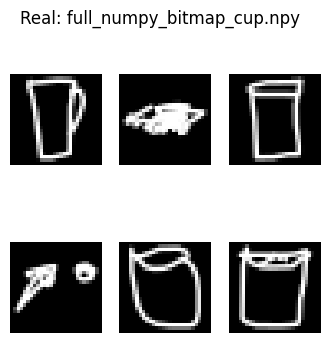

In [ ]:
for file in file_names:
    data = load_category(file)

    plt.figure(figsize=(4,4))
    for i in range(6):
        plt.subplot(2,3,i+1)
        plt.imshow(data[i][0], cmap="gray")
        plt.axis("off")

    plt.suptitle(f"Real: {file}")
    plt.show()

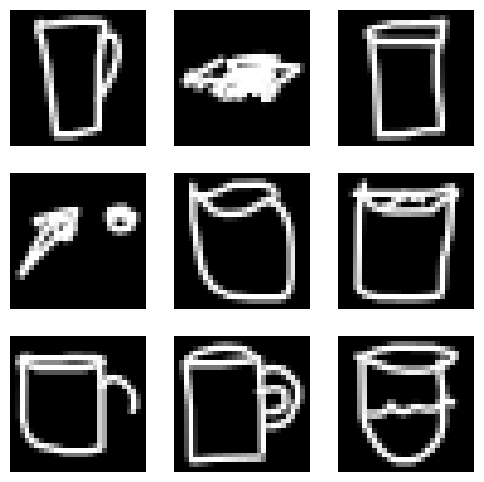

Epoch 1 Batch 0 | D: 1.306 | G: 1.561
Epoch 1 Batch 50 | D: 0.345 | G: 4.062
Epoch 1 Batch 100 | D: 0.331 | G: 5.337
Epoch 1 Batch 150 | D: 0.328 | G: 6.238
Epoch 2 Batch 0 | D: 0.330 | G: 6.297
Epoch 2 Batch 50 | D: 0.327 | G: 6.222
Epoch 2 Batch 100 | D: 0.327 | G: 6.455
Epoch 2 Batch 150 | D: 0.327 | G: 6.550
Epoch 3 Batch 0 | D: 0.328 | G: 6.630
Epoch 3 Batch 50 | D: 0.326 | G: 7.176
Epoch 3 Batch 100 | D: 0.327 | G: 7.528
Epoch 3 Batch 150 | D: 0.329 | G: 7.416
Epoch 4 Batch 0 | D: 0.327 | G: 7.515
Epoch 4 Batch 50 | D: 0.326 | G: 7.912
Epoch 4 Batch 100 | D: 0.326 | G: 8.145
Epoch 4 Batch 150 | D: 0.326 | G: 8.183
Epoch 5 Batch 0 | D: 0.326 | G: 8.247
Epoch 5 Batch 50 | D: 0.326 | G: 7.327
Epoch 5 Batch 100 | D: 0.326 | G: 7.612
Epoch 5 Batch 150 | D: 0.326 | G: 7.457
Epoch 6 Batch 0 | D: 0.326 | G: 7.581
Epoch 6 Batch 50 | D: 0.326 | G: 7.918
Epoch 6 Batch 100 | D: 0.326 | G: 7.323
Epoch 6 Batch 150 | D: 0.326 | G: 7.420
Epoch 7 Batch 0 | D: 0.326 | G: 7.499
Epoch 7 Batch 50 | D

In [ ]:
def load_category(file_name, max_samples=20000):
    data = np.load(file_name)
    data = data[:max_samples]
    data = data / 255.0
    data = (data - 0.5) / 0.5
    data = data.reshape(-1, 1, 28, 28)
    return data

def get_loader(data):
    tensor = torch.tensor(data, dtype=torch.float32).clone().detach()
    dataset = TensorDataset(tensor)

    return DataLoader(
        dataset,
        batch_size=128,
        shuffle=True,
        num_workers=0
    )

file_name = "full_numpy_bitmap_cup.npy"

data = load_category(file_name)

plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(data[i][0], cmap="gray")
    plt.axis("off")
plt.show()

loader = get_loader(data)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

G = Generator().to(device)
D = Discriminator().to(device)

g_opt = torch.optim.Adam(G.parameters(), lr=0.0002, betas=(0.5,0.999))
d_opt = torch.optim.Adam(D.parameters(), lr=0.0002, betas=(0.5,0.999))

criterion = torch.nn.BCELoss()

epochs = 25

for epoch in range(epochs):
    for batch_idx, (real,) in enumerate(loader):

        real = real.to(device)
        b = real.size(0)

        real_labels = torch.ones(b,1).to(device) * 0.9
        fake_labels = torch.zeros(b,1).to(device)

        z = torch.randn(b,100,1,1).to(device)
        fake = G(z)

        d_loss = criterion(D(real), real_labels) + \
                 criterion(D(fake.detach()), fake_labels)

        d_opt.zero_grad()
        d_loss.backward()
        d_opt.step()

        z = torch.randn(b,100,1,1).to(device)
        fake = G(z)

        g_loss = criterion(D(fake), real_labels)

        g_opt.zero_grad()
        g_loss.backward()
        g_opt.step()

        if batch_idx % 50 == 0:
            print(f"Epoch {epoch+1} Batch {batch_idx} | D: {d_loss:.3f} | G: {g_loss:.3f}")

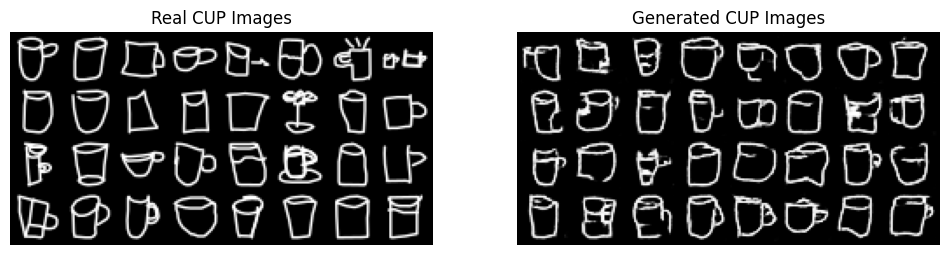

In [ ]:
real_batch, = next(iter(loader))
real_batch = real_batch[:32]

z = torch.randn(32,100,1,1).to(device)
fake_batch = G(z).detach().cpu()

real_grid = make_grid(real_batch, nrow=8, normalize=True, padding=2)
fake_grid = make_grid(fake_batch, nrow=8, normalize=True, padding=2)

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(real_grid.permute(1,2,0))
plt.axis("off")
plt.title("Real CUP Images")

plt.subplot(1,2,2)
plt.imshow(fake_grid.permute(1,2,0))
plt.axis("off")
plt.title("Generated CUP Images")

plt.show()

In [ ]:
if os.path.exists("real"):
    shutil.rmtree("real")
if os.path.exists("fake"):
    shutil.rmtree("fake")

os.makedirs("real", exist_ok=True)
os.makedirs("fake", exist_ok=True)

real_batch, = next(iter(loader))
real_batch = real_batch[:100]

for i in range(real_batch.size(0)):
    save_image(real_batch[i], f"real/{i}.png", normalize=True)

z = torch.randn(100,100,1,1).to(device)
fake_batch = G(z).detach().cpu()

for i in range(fake_batch.size(0)):
    save_image(fake_batch[i], f"fake/{i}.png", normalize=True)

fid = fid_score.calculate_fid_given_paths(
    ["real", "fake"],
    batch_size=32,
    device=device,
    dims=2048
)

print("FID Score:", fid)

100%|██████████| 4/4 [00:00<00:00,  7.09it/s]


FID Score: 64.18770409170907
